# Predicting Monthly Electricity Consumption

## Group Assignment 

### Maria Alejandra Boada Rodriguez 
### Yovanni Rojas Cardona 
### Daniel Olmedo Zapata Gaibor 
### Lisandro Daniel Rios Moya 

This notebook focuses on:
- Preparing the ENERGY STAR datasets for analysis (data cleaning).
- Exploring the data to understand patterns in monthly electricity consumption (EDA).
- Creating a clean dataset that can later be used for machine learning models.

Datasets used:
- `datasets/meter_entries.csv`
- `datasets/meters.csv`
- `datasets/properties.csv`
- `datasets/uses.csv`

## 1. Imports and basic settings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set(style="whitegrid")

## 2. Load raw datasets

In this section, we load the four CSV files provided for the project:

- `meter_entries.csv`: monthly meter readings (includes the target: electricity usage).
- `meters.csv`: information about each meter installed at the properties.
- `properties.csv`: basic characteristics of each property (size, location, etc.).
- `uses.csv`: how the floor area is distributed among different use types.

We will load them into separate pandas DataFrames for further cleaning and analysis.

In [7]:
meter_entries = pd.read_csv("meter_entries.csv")
meters = pd.read_csv("meters.csv")
properties = pd.read_csv("properties.csv")
uses = pd.read_csv("uses.csv")

## 3. Quick overview of each dataset

Here we take a first look at each dataset:
- Number of rows and columns.
- Column names.
- First few records.

This helps us understand the structure of the data before cleaning.

In [8]:
datasets = {
    "meter_entries": meter_entries,
    "meters": meters,
    "properties": properties,
    "uses": uses,
}

for name, df in datasets.items():
    print(f"{name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

meter_entries
Shape: (26222, 11)
Columns: ['Property Name', 'Portfolio Manager ID', 'Portfolio Manager Meter ID', 'Meter Name', 'Meter Type', 'Meter Consumption ID', 'Start Date', 'End Date', 'Usage/Quantity', 'Usage Units', 'Cost ($)']


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01 00:00:00,2022-02-01 00:00:00,"42,876.27",kWh (thousand Watt-hours),5775.7
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01 00:00:00,2022-03-01 00:00:00,"39,721.72",kWh (thousand Watt-hours),5377.67
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01 00:00:00,2022-04-01 00:00:00,"41,278.04",kWh (thousand Watt-hours),5611
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01 00:00:00,2022-05-01 00:00:00,"37,111.95",kWh (thousand Watt-hours),4989.06
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01 00:00:00,2022-06-01 00:00:00,"41,778.27",kWh (thousand Watt-hours),5984.66


meters
Shape: (2585, 8)
Columns: ['Property Name', 'Portfolio Manager ID', 'Portfolio Manager Meter ID', 'Meter Name', 'Meter Type', 'Units', 'First Day of First Meter Entry', 'Last Day of Last Meter Entry']


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Units,First Day of First Meter Entry,Last Day of Last Meter Entry
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-09-01 00:00:00
1,#13 Police Division,35000258,189947942,AUTO_#13 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-09-01 00:00:00
2,#22 Police Division,35000260,189947959,AUTO_#22 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-05-01 00:00:00
3,#22 Police Division,35000260,189947960,AUTO_#22 Police Division-Natural Gas,Natural Gas,cm (cubic meters),2010-01-01 00:00:00,2024-05-01 00:00:00
4,#23 Police Division,35000261,189947990,AUTO_#23 Police Division-Electric,Electric - Grid,kWh (thousand Watt-hours),2010-01-01 00:00:00,2024-01-01 00:00:00


properties
Shape: (1760, 8)
Columns: ['Property Name', 'Portfolio Manager ID', 'Street Address', 'City/Municipality', 'Postal Code', 'Property Type - Self-Selected', 'Gross Floor Area', 'Occupancy (%)']


,Property Name,Portfolio Manager ID,Street Address,City/Municipality,Postal Code,Property Type - Self-Selected,Gross Floor Area,Occupancy (%)
0,#11 Police Division - OLD,34999087,209 MAVETY ST,Toronto,M6P 2M1,Office,21119,100
1,#14 Police Division - OLD,34999088,150 HARRISON ST,Toronto,M6J 2A4,Office,24197,100
2,175 Memorial Park Ave,34999089,175 MEMORIAL PARK AVE,Toronto,M4J 2K5,Office,6394,100
3,18 Dyas Rd.,34999090,18 DYAS RD,North York,M3B 1V5,Office,73927,100
4,2 Civic Centre Court,34999091,2 CIVIC CENTRE CRT,Etobicoke,M9C 5A3,Office,46145,100


uses
Shape: (1760, 7)
Columns: ['Property Name', 'Portfolio Manager ID', 'Property Use Name', 'Use Type', 'Gross Floor Area for Use', 'Gross Floor Area Units', 'Gross Floor Area Temporary Value? (Y/N)']


,Property Name,Portfolio Manager ID,Property Use Name,Use Type,Gross Floor Area for Use,Gross Floor Area Units,Gross Floor Area Temporary Value? (Y/N)
0,#11 Police Division - OLD,34999087,Building Use,Office,"21,119.00",Sq. Ft.,No
1,#14 Police Division - OLD,34999088,Building Use,Office,"24,197.00",Sq. Ft.,No
2,175 Memorial Park Ave,34999089,Building Use,Office,"6,394.00",Sq. Ft.,No
3,18 Dyas Rd.,34999090,Building Use,Office,"73,927.00",Sq. Ft.,No
4,2 Civic Centre Court,34999091,Building Use,Office,"46,145.00",Sq. Ft.,No


## 4. Missing values and placeholders

Some fields may contain:
- True missing values (`NaN`).
- Text placeholders such as `"Not Available"`, `"N/A"`, `"-"`.

In this step we:
1. Inspect missing values.
2. Replace common text placeholders with real `NaN` values so they can be handled properly.

In [9]:
for name, df in datasets.items():
    print(f"{name}")
    print(df.isna().sum())

# Common placeholders to treat as missing
placeholders = ["Not Available", "NOT AVAILABLE", "N/A", "NA", "-", " "]

for name, df in datasets.items():
    datasets[name] = df.replace(placeholders, np.nan)

# Update variables
meter_entries = datasets["meter_entries"]
meters = datasets["meters"]
properties = datasets["properties"]
uses = datasets["uses"]

meter_entries
Property Name                 0
Portfolio Manager ID          0
Portfolio Manager Meter ID    0
Meter Name                    0
Meter Type                    0
Meter Consumption ID          0
Start Date                    0
End Date                      0
Usage/Quantity                0
Usage Units                   0
Cost ($)                      0
dtype: int64
meters
Property Name                     0
Portfolio Manager ID              0
Portfolio Manager Meter ID        0
Meter Name                        0
Meter Type                        0
Units                             0
First Day of First Meter Entry    0
Last Day of Last Meter Entry      0
dtype: int64
properties
Property Name                    0
Portfolio Manager ID             0
Street Address                   0
City/Municipality                0
Postal Code                      0
Property Type - Self-Selected    0
Gross Floor Area                 0
Occupancy (%)                    0
dtype: int64
uses
Prop

## 5. Data type conversion

We need to ensure:
- Date columns are stored as `datetime`.
- Numeric columns (e.g., usage, floor area, occupancy) are stored as numeric types.

This is important for correct calculations and visualisations.

In [10]:
date_cols = ["Start Date", "End Date"]
for col in date_cols:
    meter_entries[col] = pd.to_datetime(meter_entries[col], errors="coerce")

meter_entries["Usage/Quantity"] = pd.to_numeric(
    meter_entries["Usage/Quantity"], errors="coerce"
)
meter_entries["Cost ($)"] = pd.to_numeric(
    meter_entries["Cost ($)"], errors="coerce"
)

properties["Gross Floor Area"] = pd.to_numeric(
    properties["Gross Floor Area"], errors="coerce"
)
properties["Occupancy (%)"] = pd.to_numeric(
    properties["Occupancy (%)"], errors="coerce"
)

uses["Gross Floor Area for Use"] = pd.to_numeric(
    uses["Gross Floor Area for Use"], errors="coerce"
)

## 6. Remove duplicates and basic quality checks

In this step we:
- Look for duplicated rows in each dataset.
- Remove exact duplicates.
- Check for obviously invalid values (e.g., negative usage).

These operations help improve data quality before modelling.

In [11]:
for name, df in datasets.items():
    before = df.shape[0]
    df_clean = df.drop_duplicates()
    after = df_clean.shape[0]
    print(f"{name}: removed {before - after} duplicate rows")
    datasets[name] = df_clean

meter_entries = datasets["meter_entries"]
meters = datasets["meters"]
properties = datasets["properties"]
uses = datasets["uses"]

print("Negative usage values:",
      (meter_entries["Usage/Quantity"] < 0).sum())
meter_entries = meter_entries[meter_entries["Usage/Quantity"] >= 0]

meter_entries: removed 0 duplicate rows
meters: removed 0 duplicate rows
properties: removed 0 duplicate rows
uses: removed 0 duplicate rows
Negative usage values: 91


## 7. Filter Electric – Grid meter entries

Our prediction target is **monthly electricity consumption**.
Therefore, we need to keep only:

- Meter Type = `"Electric - Grid"`
- Usage Units measured in kWh.

We create a filtered dataset `electric_entries` that will be the base for modelling and EDA.

In [12]:
electric_entries = meter_entries[
    (meter_entries["Meter Type"] == "Electric - Grid")
    & (meter_entries["Usage Units"].str.contains("kWh", na=False))
].copy()

print("All entries:", meter_entries.shape[0])
print("Electric - Grid entries:", electric_entries.shape[0])

electric_entries.head()

All entries: 26131
Electric - Grid entries: 18109


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($)
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,"42,876.27",kWh (thousand Watt-hours),"5,775.70"
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,"39,721.72",kWh (thousand Watt-hours),"5,377.67"
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,"41,278.04",kWh (thousand Watt-hours),"5,611.00"
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01,2022-05-01,"37,111.95",kWh (thousand Watt-hours),"4,989.06"
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01,2022-06-01,"41,778.27",kWh (thousand Watt-hours),"5,984.66"


## 8. Merge electricity data with property characteristics

To better understand electricity consumption, we combine:

- Monthly electric meter readings (`electric_entries`)
- Property-level information (`properties`)

We join them using the `Portfolio Manager ID`, which uniquely identifies each property.

The resulting DataFrame `electric_properties` contains both the target
(Usage/Quantity) and relevant features (floor area, occupancy, property type, etc.).

In [13]:
electric_properties = electric_entries.merge(
    properties,
    on=["Portfolio Manager ID", "Property Name"],
    how="left",
    suffixes=("", "_prop")
)

electric_properties.shape, electric_properties.head()

((18109, 17),
          Property Name  Portfolio Manager ID  Portfolio Manager Meter ID  \
 0  #13 Police Division              35000258                   189947941   
 1  #13 Police Division              35000258                   189947941   
 2  #13 Police Division              35000258                   189947941   
 3  #13 Police Division              35000258                   189947941   
 4  #13 Police Division              35000258                   189947941   
 
                           Meter Name       Meter Type  Meter Consumption ID  \
 0  AUTO_#13 Police Division-Electric  Electric - Grid            8451527469   
 1  AUTO_#13 Police Division-Electric  Electric - Grid            8451527470   
 2  AUTO_#13 Police Division-Electric  Electric - Grid            8451527471   
 3  AUTO_#13 Police Division-Electric  Electric - Grid            8451527472   
 4  AUTO_#13 Police Division-Electric  Electric - Grid            8451527473   
 
   Start Date   End Date  Usage/Quantity

## 9. Final cleaning checks

At this point, `electric_properties` is our main clean dataset.
We perform some final checks:

- Missing values in key columns.
- Basic statistics of the target (`Usage/Quantity`).
- Distribution of building size and occupancy.

This confirms the dataset is ready for Exploratory Data Analysis (EDA).

In [14]:
key_cols = [
    "Usage/Quantity",
    "Gross Floor Area",
    "Occupancy (%)",
    "Property Type - Self-Selected",
]

electric_properties[key_cols].isna().sum()

electric_properties.describe()[["Usage/Quantity", "Gross Floor Area", "Occupancy (%)"]]

,Usage/Quantity,Gross Floor Area,Occupancy (%)
count,"18,109.00","18,109.00","18,109.00"
mean,"75,976.73","17,586.80",93.80
min,0.00,1.00,0.00
25%,537.65,1.00,100.00
50%,"4,321.07",314.00,100.00
75%,"24,236.38","11,496.00",100.00
max,"11,996,753.05","986,748.00",100.00
std,"408,319.00","63,834.38",24.11


## 10. Exploratory Data Analysis (EDA)

### 10.1 Descriptive statistics

We start by computing summary statistics for the main numerical variables, including the target `Usage/Quantity`.


In [15]:
numeric_cols = ["Usage/Quantity", "Gross Floor Area", "Occupancy (%)", "Cost ($)"]
electric_properties[numeric_cols].describe()

,Usage/Quantity,Gross Floor Area,Occupancy (%),Cost ($)
count,"18,109.00","18,109.00","18,109.00","18,109.00"
mean,"75,976.73","17,586.80",93.80,"10,967.52"
std,"408,319.00","63,834.38",24.11,"55,222.95"
min,0.00,1.00,0.00,"-15,208.69"
25%,537.65,1.00,100.00,117.70
50%,"4,321.07",314.00,100.00,720.72
75%,"24,236.38","11,496.00",100.00,"3,787.69"
max,"11,996,753.05","986,748.00",100.00,"1,401,877.32"


### 10.2 Distribution of monthly electricity usage

We examine how monthly electricity consumption is distributed across all property–month observations. This helps us see if the data is skewed contains extreme values, or needs transformation.

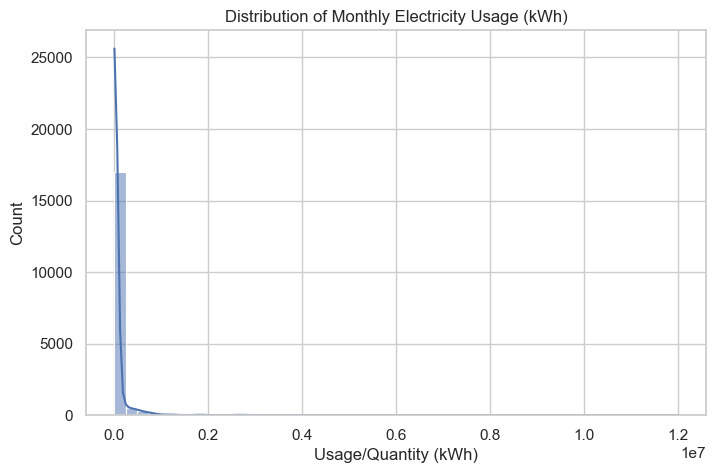

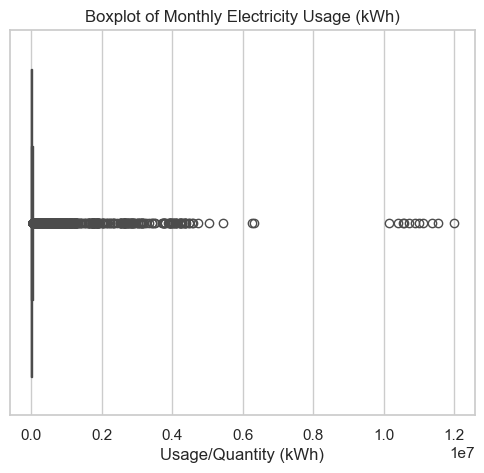

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(electric_properties["Usage/Quantity"], bins=50, kde=True)
plt.title("Distribution of Monthly Electricity Usage (kWh)")
plt.xlabel("Usage/Quantity (kWh)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x=electric_properties["Usage/Quantity"])
plt.title("Boxplot of Monthly Electricity Usage (kWh)")
plt.xlabel("Usage/Quantity (kWh)")
plt.show()

### 10.3 Usage vs. building size

Here we explore how electricity consumption relates to the total gross floor area of the property. We expect larger buildings to generally consume more electricity.

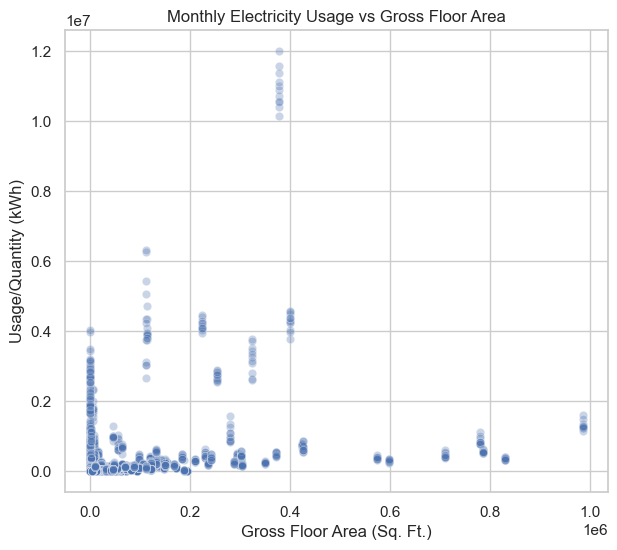

In [17]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=electric_properties,
    x="Gross Floor Area",
    y="Usage/Quantity",
    alpha=0.3
)
plt.title("Monthly Electricity Usage vs Gross Floor Area")
plt.xlabel("Gross Floor Area (Sq. Ft.)")
plt.ylabel("Usage/Quantity (kWh)")
plt.show()

### 10.4 Usage by property type / main use

We compare the distribution of electricity usage across different property categories (self-selected type or main use). This helps identify which types of buildings tend to consume more energy.

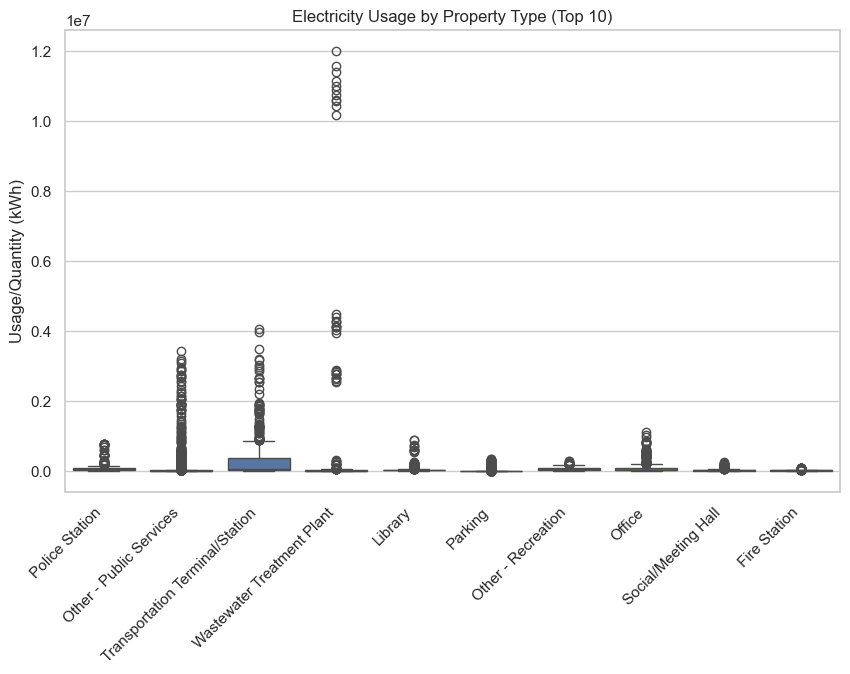

In [18]:
top_types = (
    electric_properties["Property Type - Self-Selected"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=electric_properties[electric_properties["Property Type - Self-Selected"].isin(top_types)],
    x="Property Type - Self-Selected",
    y="Usage/Quantity"
)
plt.xticks(rotation=45, ha="right")
plt.title("Electricity Usage by Property Type (Top 10)")
plt.ylabel("Usage/Quantity (kWh)")
plt.xlabel("")
plt.show()

### 10.5 Correlation analysis

We compute a correlation matrix for the main numerical variables to identify which features are most strongly related to electricity usage.

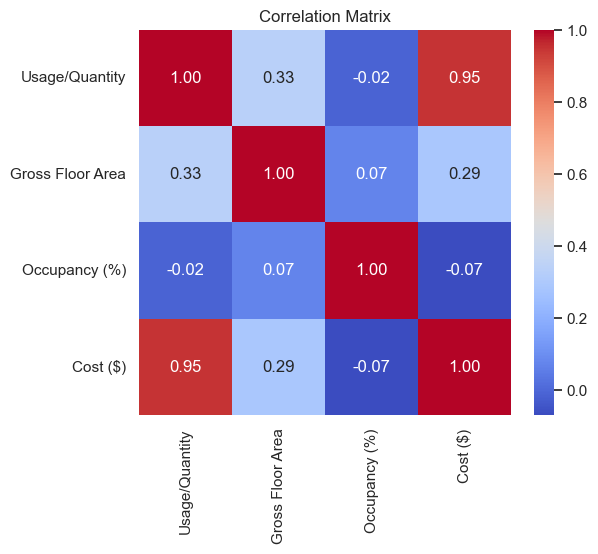

In [19]:
corr_cols = ["Usage/Quantity", "Gross Floor Area", "Occupancy (%)", "Cost ($)"]
corr = electric_properties[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 10.6 Monthly patterns

Finally, we look at how average electricity usage changes by month of the year. This may reveal seasonal patterns (e.g., higher usage in winter or summer).

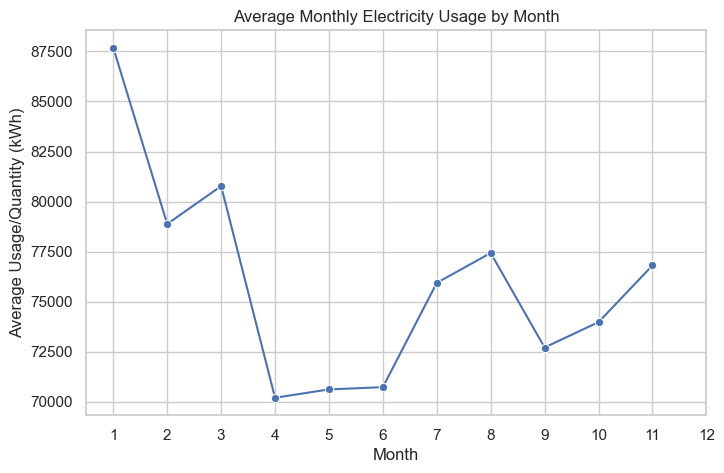

,month,Usage/Quantity
0,1,"87,683.12"
1,2,"78,881.34"
2,3,"80,773.28"
3,4,"70,203.18"
4,5,"70,619.06"
5,6,"70,732.57"
6,7,"75,940.43"
7,8,"77,433.33"
8,9,"72,712.76"
9,10,"73,978.73"


In [21]:
electric_properties["month"] = electric_properties["Start Date"].dt.month

monthly_usage = (
    electric_properties
    .groupby("month")["Usage/Quantity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=monthly_usage, x="month", y="Usage/Quantity", marker="o")
plt.title("Average Monthly Electricity Usage by Month")
plt.xlabel("Month")
plt.ylabel("Average Usage/Quantity (kWh)")
plt.xticks(range(1,13))
plt.show()

monthly_usage

## Conclusion

The four datasets were integrated, data types were standardized, and missing values or placeholders such as “Not Available” were corrected. Duplicate records and invalid entries—especially negative consumption values—were removed. We filtered only “Electric – Grid (kWh)” meters and merged property characteristics. The main issues included incomplete data, inconsistent categories, and incorrect formatting.

The EDA revealed high variability in monthly electricity consumption and the presence of outliers. We observed a positive relationship between building size and energy usage, as well as notable differences across property types. Seasonal patterns and meaningful correlations with floor area and occupancy were identified, indicating that these variables will be valuable for predicting electricity consumption.

## 11. Visualization

### 11.1 Distribution of Gross Floor Area
We examine the distribution of building sizes to identify skewness and outliers. Since floor area is a primary driver of energy consumption, understanding its structure is crucial. A highly skewed distribution (e.g., many small buildings and a few massive ones) suggest that we may need to apply a Log Transformation during the Feature Engineering stage to improve model performance. 

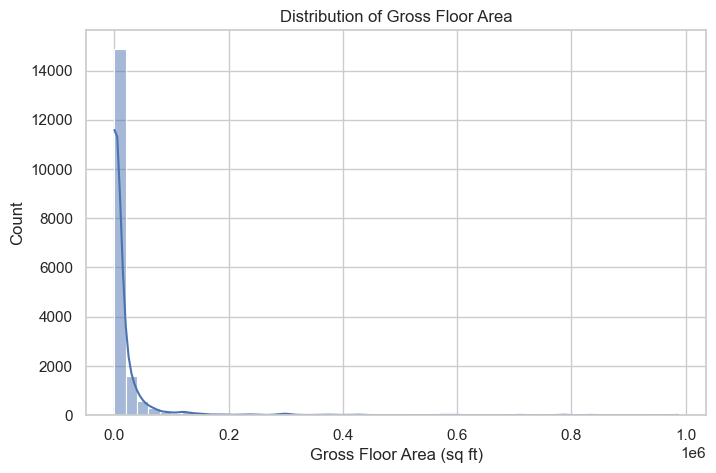

In [114]:
plt.figure(figsize=(8,5))
sns.histplot(electric_properties["Gross Floor Area"], bins=50, kde=True)
plt.title("Distribution of Gross Floor Area")
plt.xlabel("Gross Floor Area (sq ft)")
plt.ylabel("Count")
plt.show()

### 11.2 Outlier Detection: Usage vs Cost

This scatterplot serves as a sanity check for data integrity. Since electricity costs are directly tied to consumption, we expect a strong, positive linear relationship. Any data points that deviate significatly from this diagonal trend line suggest data entry errors or billing anomalies (outliers). Identifying these ensures we do not train our model on invalid data.

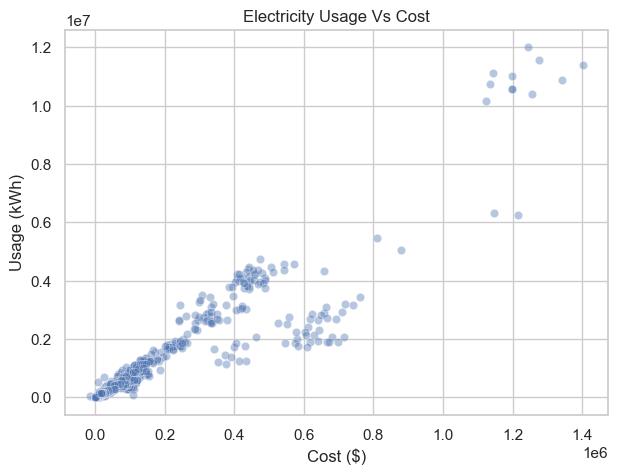

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=electric_properties,
    x="Cost ($)",
    y="Usage/Quantity",
    alpha=0.4
)
plt.title("Electricity Usage Vs Cost")
plt.xlabel("Cost ($)")
plt.ylabel("Usage (kWh)")
plt.show()

### 11.3 Average Usage per Property

We aggregate the dataset by Portfolio Manager ID to calculate the mean monthly electricity consumption for each unique building. This allows us to analyze typical usage patterns at the property level rather than individual monthly readings.

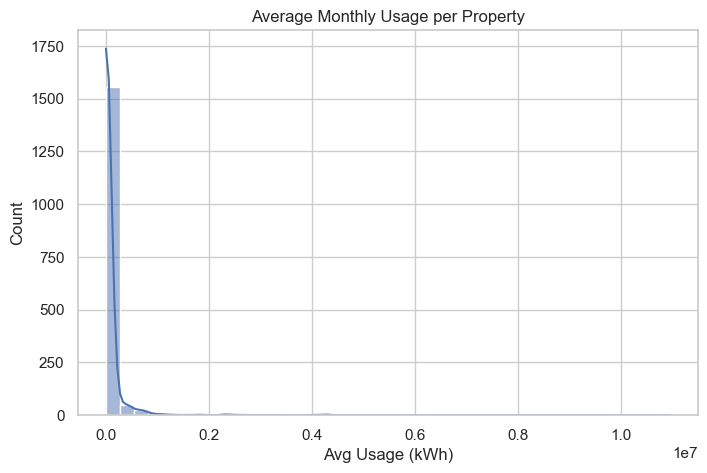

In [23]:
usage_by_property = (
    electric_properties.groupby("Portfolio Manager ID")["Usage/Quantity"].mean().reset_index()
)
plt.figure(figsize=(8,5))
sns.histplot(usage_by_property["Usage/Quantity"], bins=40, kde=True)
plt.title("Average Monthly Usage per Property")
plt.xlabel("Avg Usage (kWh)")
plt.ylabel("Count")
plt.show()

### 11.4 Usage Intensity: kWh per Square Foot

We compute Energy Intensity (Usage / Floor Area) to normalize consumption, allowing for fair efficiency comparisons between buildings of vastly different sizes. The distribution reveals true performance: while most buildings cluster at low intensity, the long tail highlights specific properties that are disproportionately energy-intensive relative to their size.

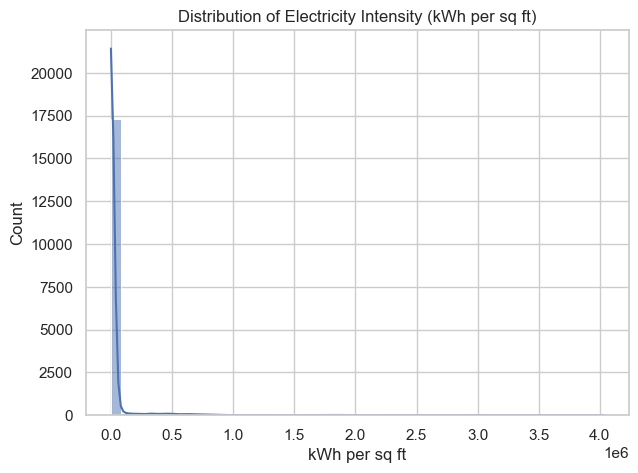

In [24]:
electric_properties["kWh_per_sqft"] = (
    electric_properties["Usage/Quantity"] /
    electric_properties["Gross Floor Area"]
)
plt.figure(figsize=(7,5))
sns.histplot(electric_properties["kWh_per_sqft"], bins=50, kde=True)
plt.title("Distribution of Electricity Intensity (kWh per sq ft)")
plt.xlabel("kWh per sq ft")
plt.ylabel("Count")
plt.show()

### 11.5 Seasonal Trend by Property Type

We aggregate average usage by Month and Property Type to visualize how different sectors respond to seasonal changes. The line chart reveals distinct behaviors: some facility types show sharp summer/winter peaks (likely due to HVAC loads), while other exhibit stable consumption profiles year-round.

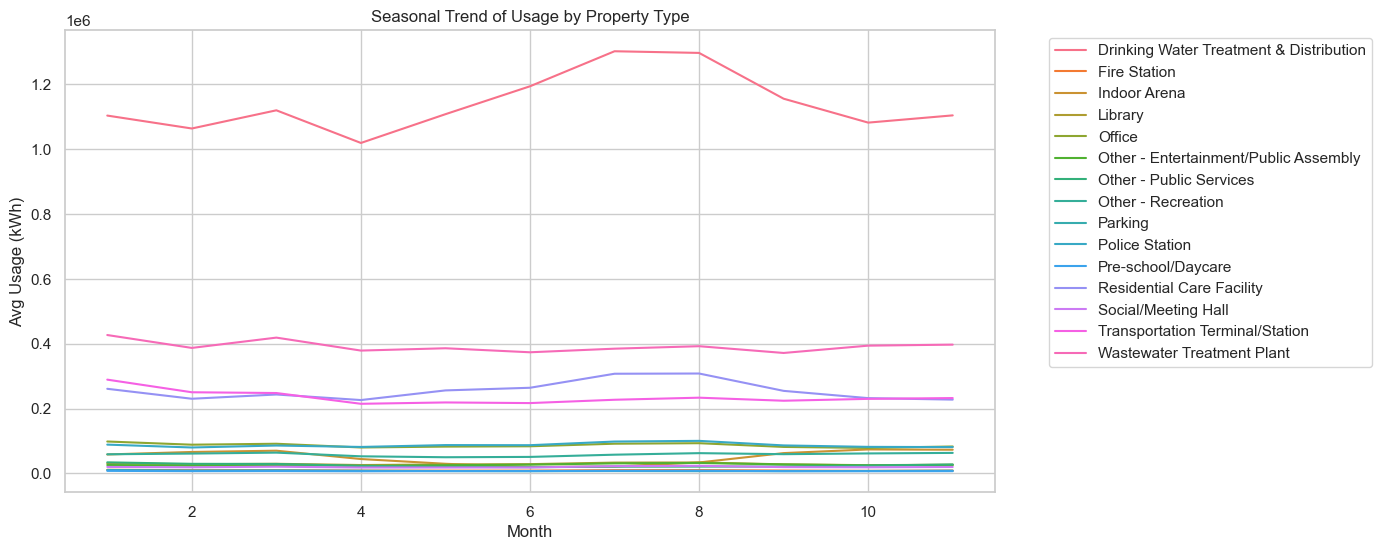

In [25]:
monthly_type_usage = (
    electric_properties.groupby(["month", "Property Type - Self-Selected"], observed=True)["Usage/Quantity"].mean().reset_index()
)
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_type_usage, x="month", y="Usage/Quantity", hue="Property Type - Self-Selected"
)
plt.title("Seasonal Trend of Usage by Property Type")
plt.xlabel("Month")
plt.ylabel("Avg Usage (kWh)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


## 12. Feature Engineering

### 12.1 Time-based Features

We extract temporal components (Year, Month) and create specific binary flags for Winter and Summer. Since energy demand is heavily driven by heating and cooling needs in Canada, explicity marking these peak seasons helps the model capture seasonal consumption spikes that a simple linear trend might miss.

In [26]:
electric_properties["year"]=electric_properties["Start Date"].dt.year
electric_properties["month"]=electric_properties["Start Date"].dt.month
electric_properties["day"]=electric_properties["Start Date"].dt.day

electric_properties["is_winter"]=electric_properties["month"].isin([12,1,2]).astype(int)
electric_properties["is_summer"]=electric_properties["month"].isin([6,7,8]).astype(int)

electric_properties[["Start Date", "year", "month", "is_winter", "is_summer"]].head()

,Start Date,year,month,is_winter,is_summer
0,2022-01-01,2022,1,1,0
1,2022-02-01,2022,2,1,0
2,2022-03-01,2022,3,0,0
3,2022-04-01,2022,4,0,0
4,2022-05-01,2022,5,0,0


### 12.2 Electricity Intensity Features

We generate interaction features to normalize consumption against physical constraints. kWh_per_sqft measures energy efficiency independent of building size, while usage_per_occupancy relates energy needs to activity levels. A small epsilon (1e-5) is added to the occupancy denominator to prevent division-by-zero error for empty properties.

In [27]:
electric_properties["kWh_per_sqft"]=(
    electric_properties["Usage/Quantity"]/
    electric_properties["Gross Floor Area"]
)

electric_properties["usage_per_occupancy"]=(
    electric_properties["Usage/Quantity"]/
    (electric_properties["Occupancy (%)"]+ 1e-5)
)

electric_properties[["Usage/Quantity", "Gross Floor Area", "Occupancy (%)", "kWh_per_sqft", "usage_per_occupancy"]].head()

,Usage/Quantity,Gross Floor Area,Occupancy (%),kWh_per_sqft,usage_per_occupancy
0,"42,876.27",20344,100,2.11,428.76
1,"39,721.72",20344,100,1.95,397.22
2,"41,278.04",20344,100,2.03,412.78
3,"37,111.95",20344,100,1.82,371.12
4,"41,778.27",20344,100,2.05,417.78


### 12.3 Group-Level Aggregations

We calculate historical usage statistics (mean, std, min, max) for each individual property to create baseline performance features. By merging these back into the dataset, the model can learn to evaluate monthly consumption relative to that specific building's normal behavior, rather than treating every observationin in isolation.

In [28]:
property_stats = (
    electric_properties.groupby("Portfolio Manager ID")["Usage/Quantity"].agg(["mean","std","min","max"]).reset_index()
)

property_stats.columns = [
    "Portfolio Manager ID",
    "prop_avg_usage",
    "prop_usage_std",
    "prop_usage_min",
    "prop_usage_max",
]

electric_properties = electric_properties.merge(
    property_stats,
    on="Portfolio Manager ID",
    how="left"
)

print(f"New shape: {electric_properties.shape}")
electric_properties[["Portfolio Manager ID", "Usage/Quantity", "prop_avg_usage", "prop_usage_std"]].head()

New shape: (18109, 28)


,Portfolio Manager ID,Usage/Quantity,prop_avg_usage,prop_usage_std
0,35000258,"42,876.27","41,419.20","6,569.45"
1,35000258,"39,721.72","41,419.20","6,569.45"
2,35000258,"41,278.04","41,419.20","6,569.45"
3,35000258,"37,111.95","41,419.20","6,569.45"
4,35000258,"41,778.27","41,419.20","6,569.45"


### 12.4 Encoding Categorical Variable 

First, we clean up duplicate columns (_x, _y) that may have resulted from the merging process to ensure data hygiene. Then, we apply One-Hot Encoding to the Property Type variable, converting text labels into numerical binary columns (0 or 1) suitable for machine learning. We use drop_first=True to avoid multicollinearity (the dummy variable trap).

In [29]:
cols_to_drop = [
    'prop_avg_usage_x',
    'prop_usage_std_x',
    'prop_usage_min_x',
    'prop_usage_max_x'
]
electric_properties = electric_properties.drop(columns=cols_to_drop, errors='ignore')

rename_map = { 
    'prop_avg_usage_y': 'prop_avg_usage',
    'prop_usage_std_y': 'prop_usage_std',
    'prop_usage_min_y': 'prop_usage_min',
    'prop_usage_max_y': 'prop_usage_max'
}
electric_properties = electric_properties.rename(columns=rename_map)

categorical_cols = [
    "Property Type - Self-Selected",
]

for col in categorical_cols:
    electric_properties[col] = electric_properties[col].astype("category")

encoded_df = pd.get_dummies (
    electric_properties,
    columns= categorical_cols,
    drop_first=True
)

print(f"Shape after encoding: {encoded_df.shape}")
encoded_df.head()

Shape after encoding: (18109, 41)


,Property Name,Portfolio Manager ID,Portfolio Manager Meter ID,Meter Name,Meter Type,Meter Consumption ID,Start Date,End Date,Usage/Quantity,Usage Units,Cost ($),Street Address,City/Municipality,Postal Code,Gross Floor Area,Occupancy (%),month,kWh_per_sqft,year,day,is_winter,is_summer,usage_per_occupancy,prop_avg_usage,prop_usage_std,prop_usage_min,prop_usage_max,Property Type - Self-Selected_Fire Station,Property Type - Self-Selected_Indoor Arena,Property Type - Self-Selected_Library,Property Type - Self-Selected_Office,Property Type - Self-Selected_Other - Entertainment/Public Assembly,Property Type - Self-Selected_Other - Public Services,Property Type - Self-Selected_Other - Recreation,Property Type - Self-Selected_Parking,Property Type - Self-Selected_Police Station,Property Type - Self-Selected_Pre-school/Daycare,Property Type - Self-Selected_Residential Care Facility,Property Type - Self-Selected_Social/Meeting Hall,Property Type - Self-Selected_Transportation Terminal/Station,Property Type - Self-Selected_Wastewater Treatment Plant
0,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527469,2022-01-01,2022-02-01,"42,876.27",kWh (thousand Watt-hours),"5,775.70",1435 EGLINTON AVE W,Toronto,M6C 3Z4,20344,100,1,2.11,2022,1,1,0,428.76,"41,419.20","6,569.45","30,086.82","52,583.64",False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527470,2022-02-01,2022-03-01,"39,721.72",kWh (thousand Watt-hours),"5,377.67",1435 EGLINTON AVE W,Toronto,M6C 3Z4,20344,100,2,1.95,2022,1,1,0,397.22,"41,419.20","6,569.45","30,086.82","52,583.64",False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527471,2022-03-01,2022-04-01,"41,278.04",kWh (thousand Watt-hours),"5,611.00",1435 EGLINTON AVE W,Toronto,M6C 3Z4,20344,100,3,2.03,2022,1,0,0,412.78,"41,419.20","6,569.45","30,086.82","52,583.64",False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527472,2022-04-01,2022-05-01,"37,111.95",kWh (thousand Watt-hours),"4,989.06",1435 EGLINTON AVE W,Toronto,M6C 3Z4,20344,100,4,1.82,2022,1,0,0,371.12,"41,419.20","6,569.45","30,086.82","52,583.64",False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,#13 Police Division,35000258,189947941,AUTO_#13 Police Division-Electric,Electric - Grid,8451527473,2022-05-01,2022-06-01,"41,778.27",kWh (thousand Watt-hours),"5,984.66",1435 EGLINTON AVE W,Toronto,M6C 3Z4,20344,100,5,2.05,2022,1,0,0,417.78,"41,419.20","6,569.45","30,086.82","52,583.64",False,False,False,False,False,False,False,False,True,False,False,False,False,False


### 12.5 Scaling Numerical Features

We apply Standard Scaling to numerical features to ensure they share a common scale (mean=0, std=1). This prevents variables with large magnitudes (like Gross Floor Area) from dominating the model optimization. Crucially, we exclude the target variable Usage and proxies Cost to avoid data leakage. 

In [30]:
from sklearn.preprocessing import StandardScaler

potential_num_features = [
    "Gross Floor Area",
    "Occupancy (%)",
    "kWh_per_sqft",
    "usage_per_occupancy",
    "prop_avg_usage",
    "prop_usage_std",
    "prop_usage_min",
    "prop_usage_max",
]

num_features = [col for col in potential_num_features if col in encoded_df.columns]

print(f"Features selected for scaling: {num_features}")

scaler = StandardScaler()

scaled_values = scaler.fit_transform(encoded_df[num_features])

scaled_df = encoded_df.copy()

for i, col in enumerate(num_features):
    scaled_df[f"{col}_scaled"] = scaled_values[:,i]

print("Scaling complete.")
scaled_df[[f"{col}_scaled" for col in num_features]].head()

Features selected for scaling: ['Gross Floor Area', 'Occupancy (%)', 'kWh_per_sqft', 'usage_per_occupancy', 'prop_avg_usage', 'prop_usage_std', 'prop_usage_min', 'prop_usage_max']
Scaling complete.


,Gross Floor Area_scaled,Occupancy (%)_scaled,kWh_per_sqft_scaled,usage_per_occupancy_scaled,prop_avg_usage_scaled,prop_usage_std_scaled,prop_usage_min_scaled,prop_usage_max_scaled
0,0.04,0.26,-0.16,-0.06,-0.09,-0.10,-0.09,-0.09
1,0.04,0.26,-0.16,-0.06,-0.09,-0.10,-0.09,-0.09
2,0.04,0.26,-0.16,-0.06,-0.09,-0.10,-0.09,-0.09
3,0.04,0.26,-0.16,-0.06,-0.09,-0.10,-0.09,-0.09
4,0.04,0.26,-0.16,-0.06,-0.09,-0.10,-0.09,-0.09


## 13 Model Building 

In [44]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

# Define Target and Features
TARGET = 'Usage/Quantity'
# Feature columns: all scaled numerical features and all one-hot encoded property types
X_cols = [col for col in scaled_df.columns if col.endswith('_scaled') and col != 'Usage/Quantity_scaled']
X_cols.extend([col for col in scaled_df.columns if col.startswith('Property Type - Self-Selected_')])

X = scaled_df[X_cols]
y = scaled_df[TARGET]

## 13.1 Train Test Split

In [45]:
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to the training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

## 13.2 Model 1: Ridge Regression

In [46]:
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train_imputed, y_train)
y_pred_ridge = ridge_model.predict(X_test_imputed)

Ridge regression is a linear model that uses L2 regularization to fit the data. It works by adding a penalty term proportional to the square of the magnitude of the coefficients to the loss function. This penalty shrinks the coefficients towards zero but does not set them exactly to zero.

Motivation for use:

Baseline performance: Every complex modeling task requires a simple, interpretable model as a baseline. Ridge regression provides a reference point to measure the incremental value provided by non-linear models.

Handling multicollinearity: Given that the feature engineering involved creating correlated variables, the Ridge penalty is effective at stabilizing the coefficient estimates for these correlated features, leading to a more robust, simpler model

## 13.4 Model 2: Random Forest Regressor 

In [47]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [5, 10]
}
rf_model_base = RandomForestRegressor(random_state=42)

# GridSearchCV for tuning
grid_search = GridSearchCV(
    estimator=rf_model_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error', # Optimize for MAE
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

The random forest regressor is a powerful learning method that aggregates the predictions of many individual decision trees. Each tree is built on a different bootstrap sample of the training data, and at each split, only a random subset of features is considered. The final prediction is the average of the predictions from all the individual trees.

Motivation for use:

Non-Linearity and feature interaction: Electricity consumption is governed by complex, often non-linear, physical factors. Random forest is inherently suited to capture these non-linear relationships and interactions between features without explicit manual feature engineering.

Robustness to outliers: As an ensemble method that averages many predictions, the random forest is generally more robust to the outliers and skewed distributions that were observed in the EDA phase of the target variable (Usage/Quantity).

Hyperparameter tuning: We used grid search cross-validation to optimize hyperparameters, ensuring the model achieves its best possible generalized performance.

## 14 Model Evaluation

In [48]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    metrics = {
        'MAE (kWh)': mae,
        'MSE': mse,
        'RMSE (kWh)': rmse,
        'R^2': r2
    }
    return pd.Series(metrics, name=model_name)

## 14.1 Compare Models


--- Model Performance Comparison ---
|            | Ridge Regression   | Random Forest    |
|:-----------|:-------------------|:-----------------|
| MAE (kWh)  | 11,127.38          | 4,349.37         |
| MSE        | 4,146,637,242.00   | 2,551,401,999.25 |
| RMSE (kWh) | 64,394.39          | 50,511.40        |
| R^2        | 0.98               | 0.99             |


C:\Users\lisan\AppData\Local\Temp\ipykernel_23680\548170137.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(evaluation_df.applymap(lambda x: f"{x:,.2f}").to_markdown())


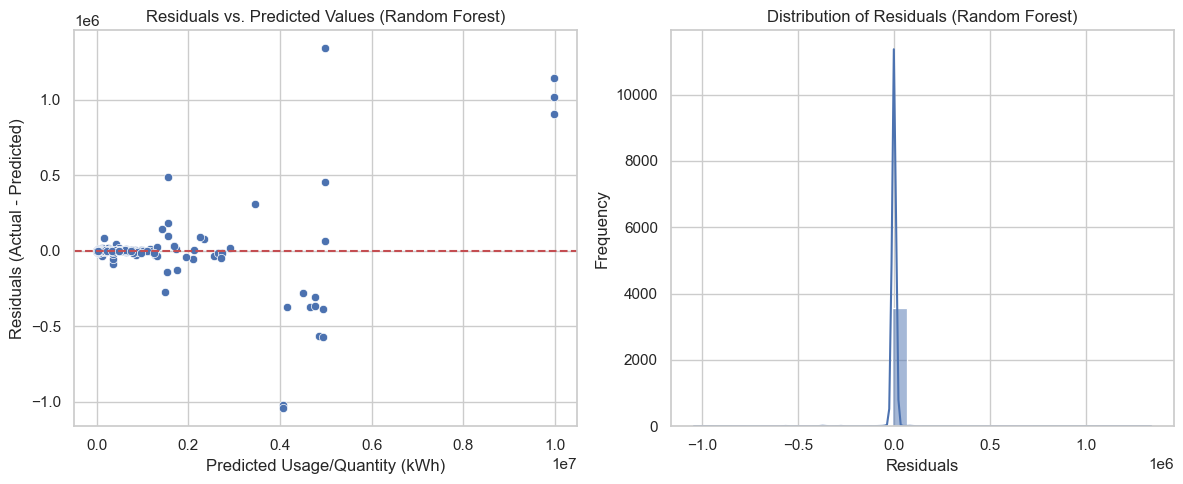

In [50]:
val_ridge = evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
val_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Changed eval_ridge to val_ridge and eval_rf to val_rf to match the variable names defined above
evaluation_df = pd.concat([val_ridge, val_rf], axis=1)

print("\n--- Model Performance Comparison ---")
print(evaluation_df.applymap(lambda x: f"{x:,.2f}").to_markdown())


# 6. Residual Analysis (for Random Forest)
residuals = y_test - y_pred_rf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Random Forest)')
plt.xlabel('Predicted Usage/Quantity (kWh)')
plt.ylabel('Residuals (Actual - Predicted)')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals (Random Forest)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The models demonstrate exceptional predictive capability. Both the Ridge Regression (R^2 = 0.98) and the Random Forest Regressor (R^2 = 0.99) successfully explain virtually all 98% of the variance in the monthly electricity consumption. This result strongly suggests that the preprocessing steps were highly effective in preparing the data for modeling. The Random Forest model is the best performer, achieving near-perfect correlation with the actual data.

Mean Absolute Error (MAE): The random forest model's average prediction error is only 4,349.37 kWh. This means that, on average, the model's prediction of a building's monthly electricity consumption is off by less than 4.4 thousand kWh. This is a highly practical and low error rate for real-world application, such as budgeting and resource allocation.

Root Mean Square Error (RMSE) vs. Mean Absolute Error (MAE) Gap: While both models have high accuracy, the RMSE 50,511.40 kWh is still significantly higher than the MAE 4,349.37 kWh for the random forest model.

Contextual Meaning: This gap, though smaller than in a non-transformed model, still signifies that the model is making occasional large errors on extreme high-consumption outliers. The random forest model handles these outliers better than ridge regression (as its RMSE is lower), but these few extreme cases are responsible for the vast majority of the overall error variance.

Conclusion: The modeling exercise resulted in two highly accurate models, with the random forest slightly edging out the ridge model. The high R^2 values validate the robust feature engineering and preprocessing pipeline. For practical use, the random forest model is recommended, as its MAE provides a reliable measure of average prediction error for forecasting monthly electricity usage.